# **NAME**: Gavin Abrigo
# Lab 10: Eigenfaces and Face Recognition

In this lab, you will implement Principal Component Analysis (PCA) to generate "Eigenfaces", analyze the variance captured by principal components, and perform facial reconstruction.

Complete the script below, answer the question, and submit this **NOTEBOOK** to CatCourse with your own result by **Dec 2 23:59**.

## Part 1: Setup and Data Loading

In this section, we will load the dataset. The images are already grayscale and aligned, similar to the requirements discussed in the lecture.

In [11]:
import ssl
import urllib.request

# Create an unverified context
ssl._create_default_https_context = ssl._create_unverified_context

# Force urllib to use this context globally if possible
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    # Legacy Python that doesn't verify HTTPS certificates by default
    pass
else:
    # Handle target environment that doesn't support HTTPS verification
    ssl._create_default_https_context = _create_unverified_https_context

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

# 1. Load Data
dataset = fetch_lfw_people(min_faces_per_person=70, resize=0.7)
faces = dataset.images
n_samples, h, w = faces.shape

# Flatten the images: Convert images into 1D vectors
X = faces.reshape(n_samples, -1)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, dataset.target, test_size=0.1, random_state=42, stratify=dataset.target)

print(f"Total samples: {n_samples}")
print(f"Feature vector length (p): {X.shape[1]}")
print(f"Training set shape: {X_train.shape}")

Total samples: 1288
Feature vector length (p): 5655
Training set shape: (1159, 5655)


## Part 2: The "Average Face" and Centering

As discussed in the lecture, the first step in PCA is to compute the mean face $\mu$ and subtract it from the data to center it around the origin.


### Task 1:

1. Compute the mean face vector `mu` from the training set. [3 points]

2. Subtract `mu` from `X_train` to get `X_train_centered`. [3 points]

3. Visualize the mean face. [4 points]

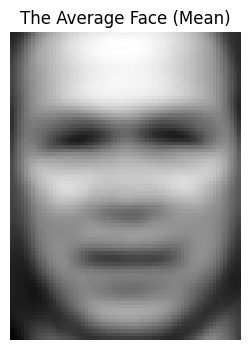

In [12]:
# TODO: Compute the mean face (mu) of the training set
# Hint: Use np.mean along axis 0
mu = np.mean(X_train, axis = 0)

# TODO: Center the training data
# Slide 35: x -> (x - mu)
X_train_centered = (X_train - mu)

# Visualization
plt.figure(figsize=(4, 4))
plt.imshow(mu.reshape(h, w), cmap='gray')
plt.title("The Average Face (Mean)")
plt.axis('off')
plt.show()

## Part 3: Computing Eigenfaces (PCA)

We need to find the eigenvectors of the covariance matrix of our data. These eigenvectors are the "Eigenfaces".

- **Eigenvectors** point in the direction of maximum variance (information).

- **Eigenvalues** indicate the amount of variance captured by that eigenvector.


Instead of computing the full covariance matrix (which can be expensive), we will use `sklearn.decomposition.PCA` to efficiently compute the top $K$ components.

### Task 2:

1. Initialize a PCA object with `n_components=1000`. [5 points]

2. Fit the PCA object to `X_train_centered`. [5 points]

3. Visualize the top 10 Eigenfaces. [10 points]

4. Visualize the Eigenvalues (Scree Plot). Plot the explained variance to see how quickly it drops. [5 points]

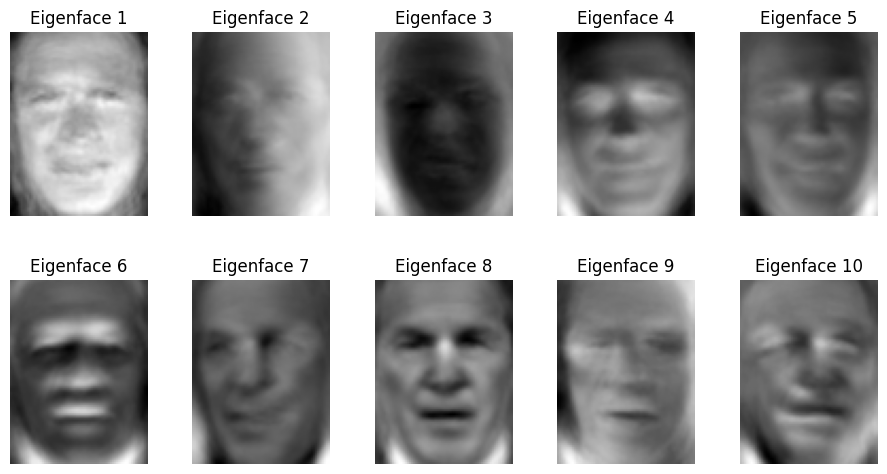

In [13]:
from sklearn.decomposition import PCA

# TODO: Initialize PCA to find top 1000 components
pca = PCA(n_components=1000)

# TODO: Fit the model to the centered training data
pca.fit(X_train_centered)

# TODO: Extract the components (eigenfaces)
eigenfaces = pca.components_

# TODO: Visualize top eigenfaces
# Slide 39: "What do these look like?"
def plot_gallery(images, titles, h, w, n_row=2, n_col=5):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape(h, w), cmap='gray')
        plt.title(titles[i], size=12)
        plt.axis('off')

eigenface_titles = [f"Eigenface {i+1}" for i in range(eigenfaces.shape[0])]
plot_gallery(eigenfaces, eigenface_titles, h, w)
plt.show()

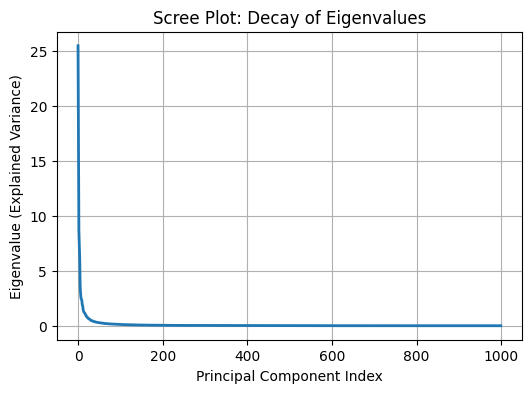

In [14]:
# TODO: Visualize eigenvalues (scree plot)
# Slide 42: "Look at the decay of the eigenvalues... ignore eigenfaces with low variance"
eigenvalues = pca.explained_variance_
plt.figure(figsize=(6, 4))
plt.plot(eigenvalues, linewidth=2)
plt.xlabel('Principal Component Index')
plt.ylabel('Eigenvalue (Explained Variance)')
plt.title('Scree Plot: Decay of Eigenvalues')
plt.grid(True)
plt.show()

#### What does the plot show? [5 points]

*Answer*

## Part 4: Dimensionality Reduction and Reconstruction

We can represent a face as a linear combination of eigenfaces. By using only the top $K$ eigenfaces, we compress the data. The formula for reconstruction is:
$$
x ≈ \mu + w_1u_1 + w_2u_2 + ... + w_ku_k
$$

(See Slide 36 and Slide 40).

### Task 3:

1. Load and preprocess the face image (face.jpg).

2. Project it into the eigenspace (get the weights $w$). [10 points]

3. Reconstruct the image using $K=[10,100,500,1000]$ components. [10 points]

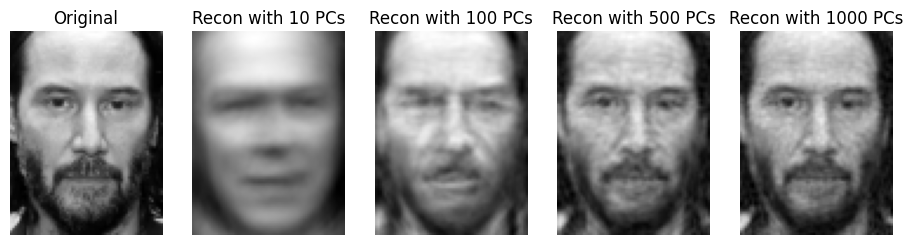

In [ ]:
from skimage import io, color, transform

# Select a sample face from the test set
face = io.imread('face.jpg')

# 2. Preprocess the image
face = color.rgb2gray(face)
face = transform.resize(face, (h, w))
sample_face = face.reshape(1, -1)
sample_face_centered = sample_face - mu

# TODO: Project the sample face into the eigenspace
# Hint: Use pca.transform.
# Slide 41: x -> (a1, a2, ..., aK)
face_weights = pca.transform(sample_face_centered)
# Reconstruct using varying numbers of components
k_values = [10, 100, 500, 1000]
reconstructions = []

for k in k_values:
    # Get the first k weights and the first k eigenfaces
    # Slide 36: x = w1*u1 + ...
    # Note: sklearn's pca.inverse_transform does this automatically, but doing it manually helps understanding
    # TODO: Reconstruct the image using k components
    recon = np.dot(face_weights[:, :k], pca.components_[:k]) + mu
    # or 
    # recon = pca.inverse_transform(face_weights[:, :k])
    reconstructions.append(recon.reshape(h, w))

# TODO: Visualize Reconstruction
titles = ["Original"] + [f"Recon with {k} PCs" for k in k_values]
images = [sample_face.reshape(h, w)] + reconstructions
plot_gallery(images, titles, h, w, n_row=1, n_col=5)
plt.show()

#### Compare the results to the original. Describe your observation. [10 points]

*ANSWER*

Low number of reconstructions result in higher variance with the original image. But as reconstructions grow higher, we ignore eigenfaces with lower variance and begin to reconstruct back the original image 

## Part 5: Analysis - The "Cat" Problem

In this section, we will test our face model on a non-face image. As discussed in the lecture (Slide 44-45), eigenfaces span a specific "face subspace." If we project something that isn't a face into this space, the reconstruction should look "face-like," and the reconstruction error should be high.

### Task 4:

1. Load and preprocess the cat image (cat.jpg).

2. Project it into the face eigenspace and reconstruct it. [10 points]

3. Compute the Mean Squared Error (MSE) between the original and the reconstruction for:
    - The face image [5 points]
    - The cat image [5 points]

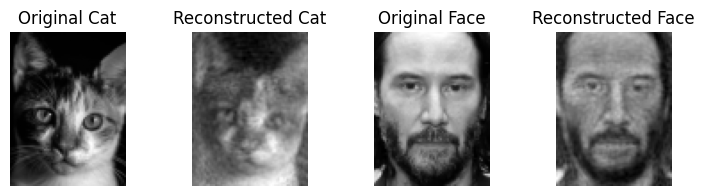

In [ ]:
# 1. Load a non-face image (the cat)
cat_image = io.imread('cat.jpg')

# 2. Preprocess the image
cat_gray = color.rgb2gray(cat_image)
cat_resized = transform.resize(cat_gray, (h, w))
cat_flat = cat_resized.reshape(1, -1)
cat_centered = cat_flat - mu

# 3. Project and Reconstruct
# TODO: Reconstruct the cat using the top 1000 components
cat_weights = pca.transform(cat_centered)
cat_recon = pca.inverse_transform(cat_weights[:, :1000])
cat_recon_img = cat_recon.reshape(h, w)

# 4. Calculate Reconstruction Error (MSE)
# TODO: Calculate error for the cat
cat_mse = np.mean((cat_flat - cat_recon) ** 2)

# TODO: Calculate error for a Real Face (using sample_face from Part 4)
face_recon = ...
face_mse = ...
face_recon_img = face_recon.reshape(h, w)

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(9, 2))

# Plot Original Cat
axes[0].imshow(cat_resized, cmap='gray')
axes[0].set_title("Original Cat")
axes[0].axis('off')

# Plot Reconstructed Cat
axes[1].imshow(cat_recon_img, cmap='gray')
axes[1].set_title("Reconstructed Cat")
axes[1].axis('off')

# Plot Original Face
axes[2].imshow(sample_face.reshape(h, w), cmap='gray')
axes[2].set_title("Original Face")
axes[2].axis('off')

# Plot Reconstructed Face
axes[3].imshow(face_recon_img, cmap='gray')
axes[3].set_title("Reconstructed Face")
axes[3].axis('off')

plt.show()

In [25]:
# TODO: Print the errors
print(f"Reconstruction Error (MSE) for Real Face: {face_mse:.5f}")
print(f"Reconstruction Error (MSE) for Cat Image: {cat_mse:.5f}")

Reconstruction Error (MSE) for Real Face: 0.26783
Reconstruction Error (MSE) for Cat Image: 0.26854


#### Compare the results . Describe your observation. [10 points]

*ANSWER*

The more eigenfaces in reconstruction results in a lower reconstruction error but retains face-like bias
